# Cognifyz Technologies – Data Science Internship
## Level 3 Tasks
**Tasks:** Predictive Modeling | Customer Preference Analysis | Data Visualization


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('D:\Projects\cognifyz-data-science-internship\cognifyz-data-science-internship\Dataset .csv', encoding='latin-1')
print(f"Dataset shape: {df.shape}")
df.head(3)


Dataset shape: (9551, 21)


,ï»¿Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270


---
## Task 1 – Predictive Modeling
Build regression models to predict Aggregate Rating, compare performance.


In [3]:
# Preprocessing
df_model = df.copy()
df_model['Has Table Booking Enc'] = (df_model['Has Table booking'] == 'Yes').astype(int)
df_model['Has Online Delivery Enc'] = (df_model['Has Online delivery'] == 'Yes').astype(int)
df_model['Name Length'] = df_model['Restaurant Name'].astype(str).apply(len)
df_model['Address Length'] = df_model['Address'].astype(str).apply(len)

# Encode City and Cuisines
le = LabelEncoder()
df_model['City Enc'] = le.fit_transform(df_model['City'].astype(str))
df_model['Cuisines Enc'] = le.fit_transform(df_model['Cuisines'].fillna('Unknown').astype(str))

features = ['Price range','Has Table Booking Enc','Has Online Delivery Enc',
            'Name Length','Address Length','City Enc','Cuisines Enc','Votes',
            'Average Cost for two']
target = 'Aggregate rating'

df_clean = df_model[features + [target]].dropna()
X = df_clean[features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")


Train size: 7640, Test size: 1911


In [4]:
# Train & evaluate 3 models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=8, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results.append({'Model': name, 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'R²': round(r2,4)})
    print(f"{name:20s} | MAE={mae:.4f} | RMSE={rmse:.4f} | R²={r2:.4f}")

results_df = pd.DataFrame(results)


Linear Regression    | MAE=1.0659 | RMSE=1.2870 | R²=0.2723
Decision Tree        | MAE=0.2177 | RMSE=0.3340 | R²=0.9510
Random Forest        | MAE=0.1994 | RMSE=0.3067 | R²=0.9587


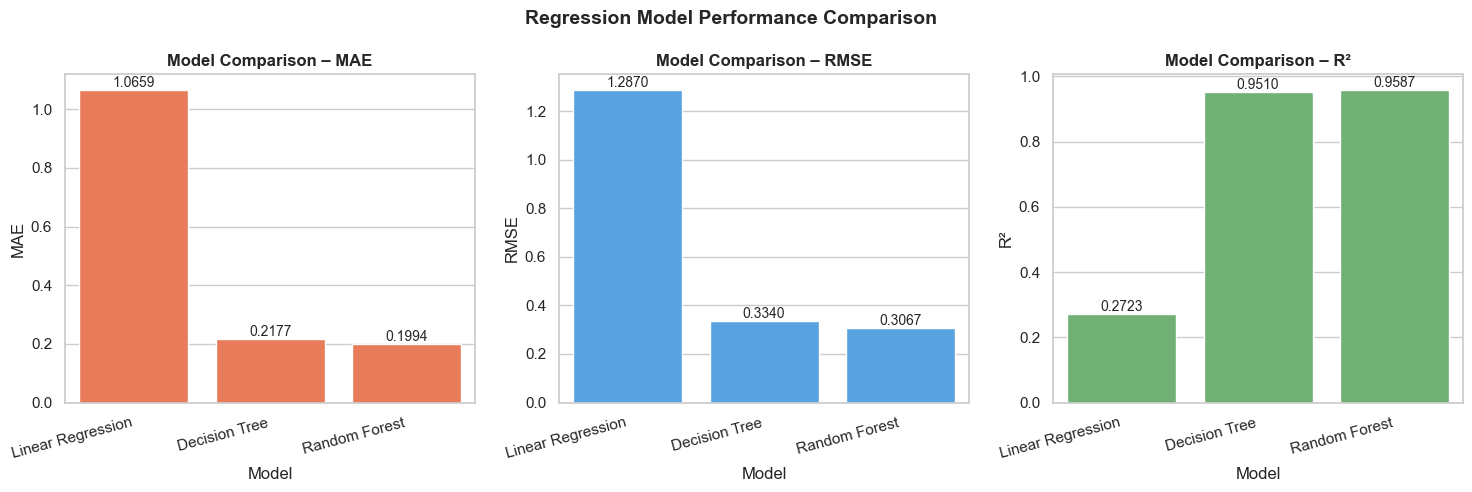


Best model by R²: Random Forest


In [5]:
# Visualise model comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['MAE', 'RMSE', 'R²']
colors = ['#FF7043', '#42A5F5', '#66BB6A']

for ax, metric, color in zip(axes, metrics, colors):
    sns.barplot(data=results_df, x='Model', y=metric, ax=ax, color=color)
    ax.set_title(f'Model Comparison – {metric}', fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.4f}', (p.get_x()+p.get_width()/2, p.get_height()),
                    ha='center', va='bottom', fontsize=10)

plt.suptitle('Regression Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('l3_t1_model_comparison.png', dpi=150)
plt.show()
print("\nBest model by R²:", results_df.loc[results_df['R²'].idxmax(), 'Model'])


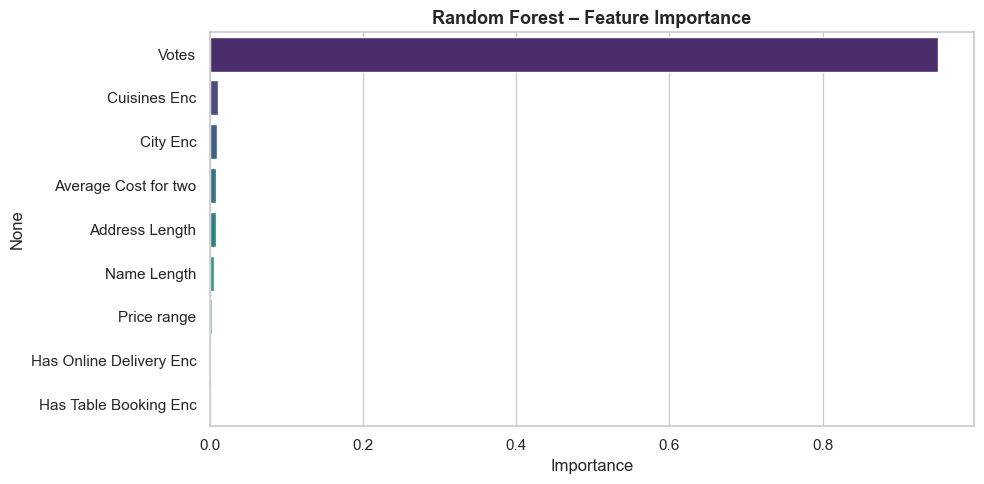

In [6]:
# Feature importance from Random Forest
rf_model = models['Random Forest']
feat_imp = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('Random Forest – Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('l3_t1_feature_importance.png', dpi=150)
plt.show()


---
## Task 2 – Customer Preference Analysis
1. Relationship between cuisine type and rating  
2. Most popular cuisines by votes  
3. Cuisines that tend to receive higher ratings


In [7]:
# Explode multi-cuisine column
cuisine_df = df.copy()
cuisine_df['Cuisines'] = cuisine_df['Cuisines'].fillna('Unknown')
cuisine_df = cuisine_df.assign(Cuisine=cuisine_df['Cuisines'].str.split(', ')).explode('Cuisine')
cuisine_df['Cuisine'] = cuisine_df['Cuisine'].str.strip()

# Top 15 cuisines by number of restaurants
top15 = cuisine_df['Cuisine'].value_counts().head(15)
print("Top 15 Cuisines by restaurant count:")
print(top15)


Top 15 Cuisines by restaurant count:
Cuisine
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Street Food      562
American         390
Pizza            381
Mithai           380
Burger           251
Name: count, dtype: int64



Top 15 Cuisines by Total Votes:
Cuisine
North Indian     595981
Chinese          364351
Italian          329265
Continental      288255
Fast Food        184058
American         183117
Cafe             177568
Mughlai          151946
Desserts         105889
Asian            104303
European         103309
South Indian      80962
Mediterranean     80538
Pizza             78179
Burger            76747
Name: Votes, dtype: int64


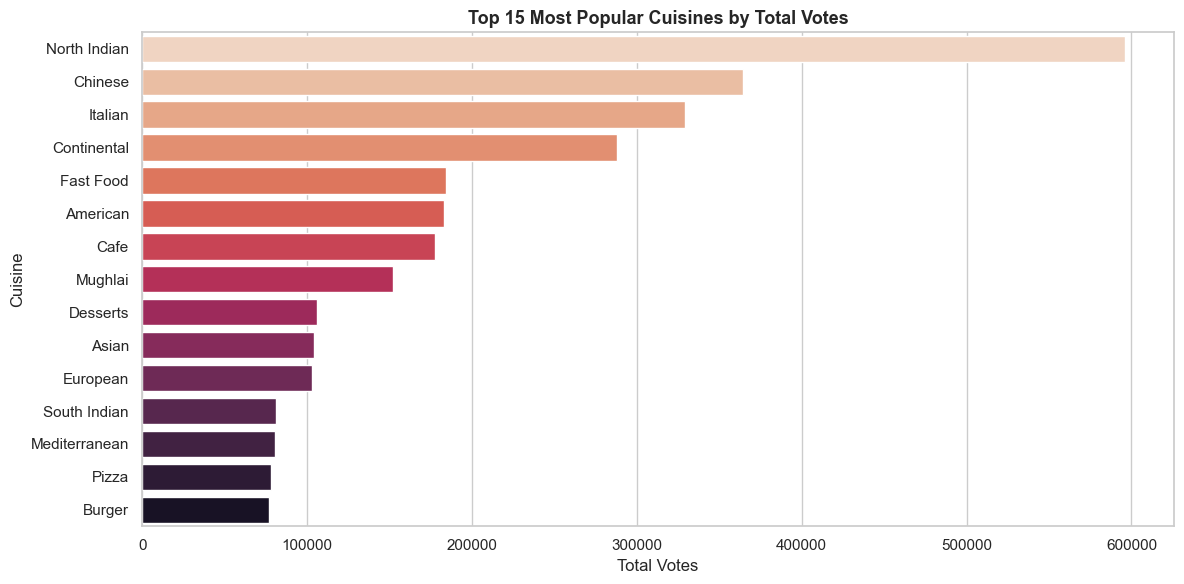

In [8]:
# 2b. Most popular by votes
cuisine_votes = cuisine_df.groupby('Cuisine')['Votes'].sum().sort_values(ascending=False).head(15)
print("\nTop 15 Cuisines by Total Votes:")
print(cuisine_votes)

plt.figure(figsize=(12,6))
sns.barplot(x=cuisine_votes.values, y=cuisine_votes.index, palette='rocket_r')
plt.title('Top 15 Most Popular Cuisines by Total Votes', fontsize=13, fontweight='bold')
plt.xlabel('Total Votes')
plt.tight_layout()
plt.savefig('l3_t2_cuisine_votes.png', dpi=150)
plt.show()


Top 15 Cuisines by Average Rating (min 50 restaurants):
           Cuisine  Avg_Rating  Count
116       Sandwich    4.066038     53
128          Steak    3.985484     62
131          Sushi    3.973333     75
87   Mediterranean    3.948214    112
65          Indian    3.918571     70
48        European    3.910811    148
118        Seafood    3.862069    174
7            Asian    3.815021    233
72        Japanese    3.797037    135
88         Mexican    3.723204    181
2         American    3.661538    390
137           Thai    3.659829    234
70         Italian    3.562042    764
24          Burger    3.520717    251
37     Continental    3.518750    736


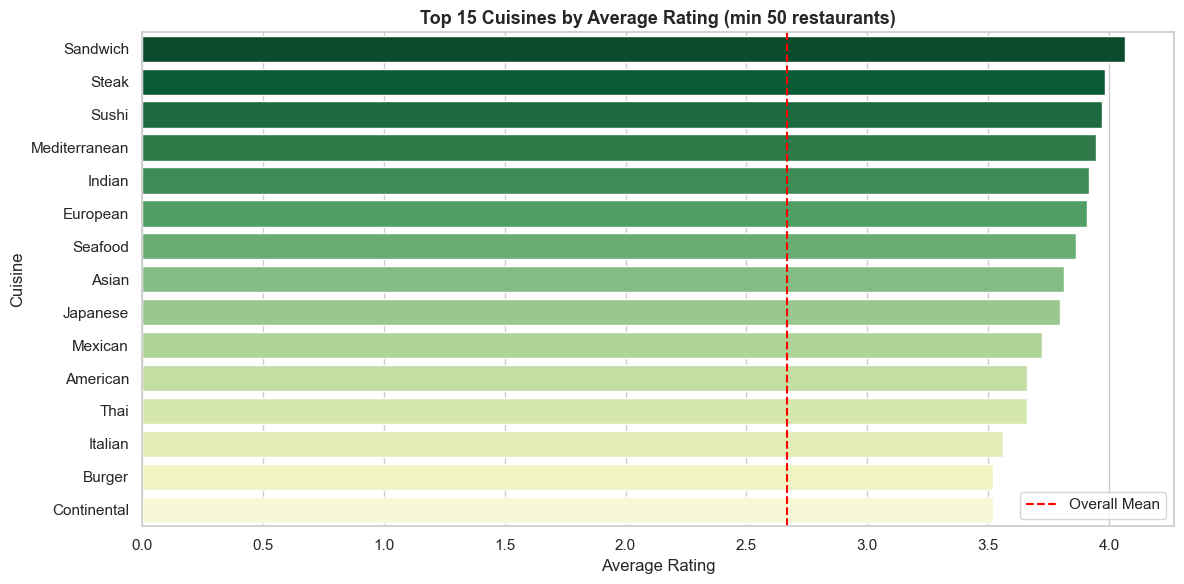

In [9]:
# 2c. Cuisines with highest average ratings (min 50 restaurants)
cuisine_rating = cuisine_df.groupby('Cuisine').agg(
    Avg_Rating=('Aggregate rating','mean'),
    Count=('Aggregate rating','count')
).reset_index()
cuisine_rating = cuisine_rating[cuisine_rating['Count'] >= 50].sort_values('Avg_Rating', ascending=False).head(15)
print("Top 15 Cuisines by Average Rating (min 50 restaurants):")
print(cuisine_rating)

plt.figure(figsize=(12,6))
sns.barplot(data=cuisine_rating, x='Avg_Rating', y='Cuisine', palette='YlGn_r')
plt.title('Top 15 Cuisines by Average Rating (min 50 restaurants)', fontsize=13, fontweight='bold')
plt.xlabel('Average Rating')
plt.axvline(df['Aggregate rating'].mean(), color='red', linestyle='--', label='Overall Mean')
plt.legend()
plt.tight_layout()
plt.savefig('l3_t2_cuisine_rating.png', dpi=150)
plt.show()


---
## Task 3 – Data Visualization
1. Distribution of ratings  
2. Average ratings by cuisine and city  
3. Relationship between features and target variable


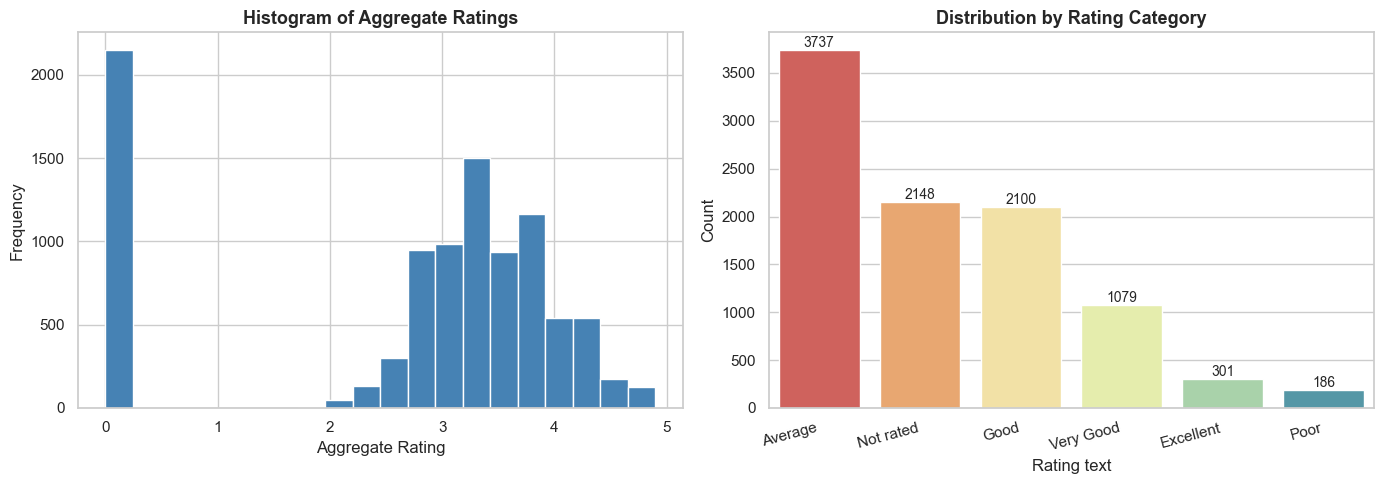

In [10]:
# 3a. Distribution of aggregate ratings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Aggregate rating'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram of Aggregate Ratings', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Aggregate Rating')
axes[0].set_ylabel('Frequency')

# Bar chart by rating text
rating_text_counts = df['Rating text'].value_counts()
sns.barplot(x=rating_text_counts.index, y=rating_text_counts.values, ax=axes[1],
            palette='Spectral')
axes[1].set_title('Distribution by Rating Category', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x()+p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('l3_t3_rating_dist.png', dpi=150)
plt.show()


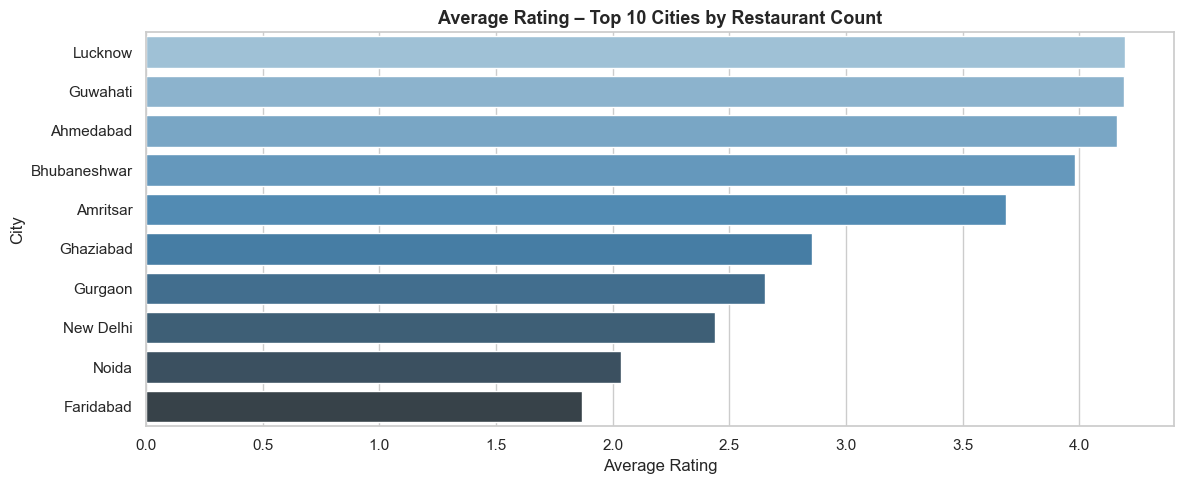

In [11]:
# 3b. Average ratings by top cities
top_cities = df['City'].value_counts().head(10).index
city_rating = df[df['City'].isin(top_cities)].groupby('City')['Aggregate rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(x=city_rating.values, y=city_rating.index, palette='Blues_d')
plt.title('Average Rating – Top 10 Cities by Restaurant Count', fontsize=13, fontweight='bold')
plt.xlabel('Average Rating')
plt.tight_layout()
plt.savefig('l3_t3_city_rating.png', dpi=150)
plt.show()


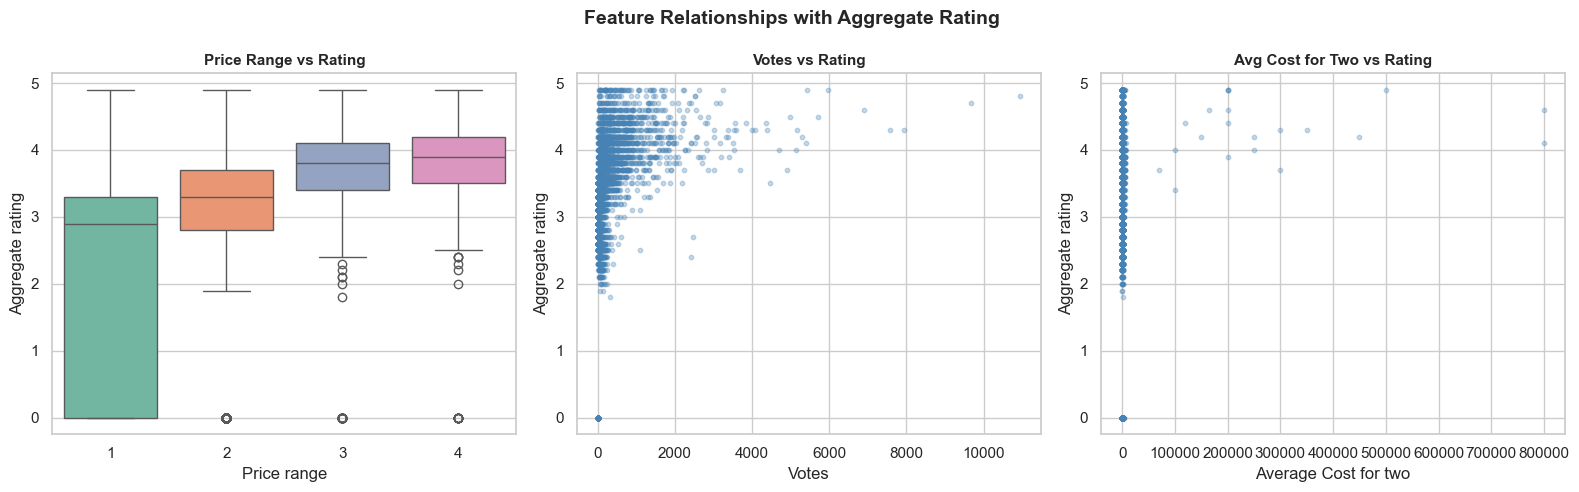

In [12]:
# 3c. Pairplot: key features vs Aggregate rating
viz_cols = ['Price range','Votes','Average Cost for two','Aggregate rating']
df_viz = df[viz_cols].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [('Price range','Aggregate rating'),
         ('Votes','Aggregate rating'),
         ('Average Cost for two','Aggregate rating')]
titles = ['Price Range vs Rating','Votes vs Rating','Avg Cost for Two vs Rating']

for ax, (x, y), title in zip(axes, pairs, titles):
    if df_viz[x].nunique() <= 10:
        sns.boxplot(data=df_viz, x=x, y=y, ax=ax, palette='Set2')
    else:
        ax.scatter(df_viz[x], df_viz[y], alpha=0.3, color='steelblue', s=10)
        ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Feature Relationships with Aggregate Rating', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('l3_t3_feature_vs_rating.png', dpi=150)
plt.show()


---
## ✅ Level 3 Complete